# Poker, uncertainty, and Monte Carlo

**Live question:** How many simulated games are enough to trust an estimated poker equity?

In [1]:
import os

os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import numpy as np
import matplotlib.pyplot as plt

from poker import DECK, hand_score

ModuleNotFoundError: No module named 'numpy'

## First, inspect the deck

The provided variable `DECK` contains the original poker deck. How is each card described? How many cards are in the deck?



In [3]:
print(DECK)
print("Number of cards in the original deck:", len(DECK))

NameError: name 'DECK' is not defined

## The situation after the flop

Your two private cards and the three-card flop are known. The opponent may already be holding two cards, but we do not know their identities; the turn and river are also unknown. To simulate one possible completion, we assign cards to all four unknown positions.

**Before you evaluate the code below:** How many unknown cards affect the result of the game? After assigning those cards, how many cards will remain unused? Think about your answers, then check them with the code.

| Your private cards | Shared cards already visible | Still unknown |
|---|---|---|
| **A♥ K♥** | **Q♥ J♥ 2♣** | opponent's 2 cards + turn and river (the other two shared cards) |

<img src="poker-table-after-flop.png" alt="Poker table after flop" width="500">

Each player ultimately has seven available cards: two private cards plus the same five community cards. 

We provided code that chooses the best five-card poker hand. We will not study poker-hand rankings during this activity.

In [3]:
your_cards = ("Ah", "Kh")
known_community_cards = ("Qh", "Jh", "2c")
known_cards = your_cards + known_community_cards

unknown_cards = []
for card in DECK:
    if card not in known_cards:
        unknown_cards.append(card)

number_unknown_cards_affecting_result = 4
number_cards_not_used = len(unknown_cards) - number_unknown_cards_affecting_result

print("Known cards:", known_cards)
print("Unknown cards before the draw:", len(unknown_cards))
print("Unknown cards affecting game results:", number_unknown_cards_affecting_result)
print("Cards not used in this simulated game:", number_cards_not_used)

Known cards: ('Ah', 'Kh', 'Qh', 'Jh', '2c')
Unknown cards before the draw: 47
Unknown cards affecting game results: 4
Cards not used in this simulated game: 43


**How can we select a random card from the card deck?**

We will use the [`numpy.random.Generator`](https://numpy.org/doc/stable/reference/random/generator.html) class and its [`choice()` method](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html).




In [7]:
seed = 356
rng = np.random.default_rng(seed)
rng.choice(DECK, size=4)

array(['2d', '5h', '2c', '7c'], dtype='<U2')

## One simulated game

How can we now simulate assigning the opponent's two unknown card identities and drawing the last two community cards?

Read this function from top to bottom. The important steps are visible: remove known cards, draw unknown cards, build the shared board, and compare the hands.


In [31]:
def play_round(your_cards, known_community, rng, print_info=False):
    # Cards that have already been dealt
    known_cards = your_cards + known_community

    # Create a deck containing only cards that are still available
    available_cards = []
    for card in DECK:
        if card not in known_cards:
            available_cards.append(card)

    # Assign the opponent's two unknown cards and draw the missing community cards
    drawn_cards = rng.choice(
        available_cards, replace=False, size=4,
    )
    #added the replace=Flase fix the issue
    # Separate the draw and finish the shared community cards
    opponent_cards = tuple(drawn_cards[:2])
    remaining_community_cards = tuple(drawn_cards[2:])
    community_cards = known_community + remaining_community_cards

    # Let the provided helper compare the completed hands
    your_score = hand_score(your_cards + community_cards)
    opponent_score = hand_score(opponent_cards + community_cards)

    if print_info:
        print("Your hand:", tuple(str(card) for card in your_cards + community_cards))
        print("Opponent hand:", tuple(str(card) for card in opponent_cards + community_cards))

    if your_score > opponent_score:
        return "win"
    elif your_score == opponent_score:
        return "tie"
    else:
        return "lose"

In [32]:
for round_number in range(5):
    print("Game", round_number + 1)
    result = play_round(your_cards, known_community_cards, rng, print_info=True)
    print("Result ->", result)
    print()


Game 1
Your hand: ('Ah', 'Kh', 'Qh', 'Jh', '2c', '3d', 'Ac')
Opponent hand: ('Ks', 'Tc', 'Qh', 'Jh', '2c', '3d', 'Ac')
Result -> lose

Game 2
Your hand: ('Ah', 'Kh', 'Qh', 'Jh', '2c', '3d', '5c')
Opponent hand: ('4c', '6c', 'Qh', 'Jh', '2c', '3d', '5c')
Result -> lose

Game 3
Your hand: ('Ah', 'Kh', 'Qh', 'Jh', '2c', '5c', 'Ts')
Opponent hand: ('5h', '4h', 'Qh', 'Jh', '2c', '5c', 'Ts')
Result -> win

Game 4
Your hand: ('Ah', 'Kh', 'Qh', 'Jh', '2c', '5h', '2s')
Opponent hand: ('8s', 'Kd', 'Qh', 'Jh', '2c', '5h', '2s')
Result -> win

Game 5
Your hand: ('Ah', 'Kh', 'Qh', 'Jh', '2c', 'Jc', 'Ac')
Opponent hand: ('Qc', '9d', 'Qh', 'Jh', '2c', 'Jc', 'Ac')
Result -> win



**The function above has a bug.** Can you fix it?



## From poker words to a numerical experiment

A computer can count `"win"`, `"tie"`, and `"lose"`, but a Monte Carlo estimate needs numerical outcomes that can be averaged. Poker equity gives full credit for a win and half as much credit for a tie.

> **Try this:** We want to do this conversion without changing `play_round`. Define the function `outcome_value` to perform the conversion:

In [43]:
def outcome_value(result):
    # result is the string output from function play_round
    # value is the float number corresponding to result
    # value = ...
    if result == "win":
        value = 1.0
    elif result == "tie":
        value = 0.5
    else:
        value = 0.0
    return value

In [44]:
example_results = ["win", "lose", "tie", "win"]
example_values = []

for result in example_results:
    example_values.append(outcome_value(result))

print("Poker outcomes:", example_results)
print("Numerical outcomes:", example_values)
print("Equity for these four games:", np.mean(example_values))

Poker outcomes: ['win', 'lose', 'tie', 'win']
Numerical outcomes: [1.0, 0.0, 0.5, 1.0]
Equity for these four games: 0.625


## Build one Monte Carlo estimate

One call to `play_round` gives one random outcome. Repeating it `N` times and averaging the numerical outcomes estimates equity. Thus `N` is the number of games per equity estimate.

The function `estimate_equity` contains a common mistake students make when implementing Monte Carlo simulations. **Can you identify and fix the bug?**



In [46]:
def estimate_equity(N, your_cards, known_community, rng):


    outcomes = []

    for _ in range(N):
        result = play_round(your_cards, known_community, rng)
        value = outcome_value(result)
        outcomes.append(value)

    return np.mean(outcomes)

N = 1000
equity = estimate_equity(N, your_cards, known_community_cards, rng)
print("Estimated equity:", equity)

#mistake: same seed

Estimated equity: 0.7615


## Repeat the entire estimate

Now each numerical experiment contains `N` games and produces one equity estimate. Repeating the entire experiment reveals the **sampling variability of the estimate**.

**Try this:** Compute one equity estimate from each experiment. Define the function `repeated_estimates`:

In [49]:
def repeated_estimates(M, N, your_cards, known_community, rng):
    # M: number of numerical experiments
    # N: number of games
    # array_estimates: has the equity estimate for each numerical experiment (shape is (M,))

    # array_estimates = ...
    estimates = []
    for i in range(M):
        equity = estimate_equity(N, your_cards, known_community, rng)
        estimates.append(equity)
    
    
    return np.array(estimates)

## How does `N` change the estimate?

> **Predict before we run this:** Which distribution should be wider: `N = 100` or `N = 1,600`? What should happen to the center?

> **While it runs:** Each row of `array_estimates` requires `M * N` simulated games. How much more work does the largest `N` require than the smallest?



In [50]:
N_values = [100, 400, 1600]
M = 100
estimates_by_N = {}

for N in N_values:
    estimates = repeated_estimates(
        M, N, your_cards, known_community_cards, rng
    )
    estimates_by_N[N] = estimates

    print(
        "N =", N,
        "  mean =", np.mean(estimates),
        "  estimated standard error =", np.std(estimates, ddof=1),
    )


N = 100   mean = 0.7694499999999997   estimated standard error = 0.040532410027362825
N = 400   mean = 0.7611624999999997   estimated standard error = 0.02139784796953359
N = 1600   mean = 0.7625718749999999   estimated standard error = 0.010805512700425911


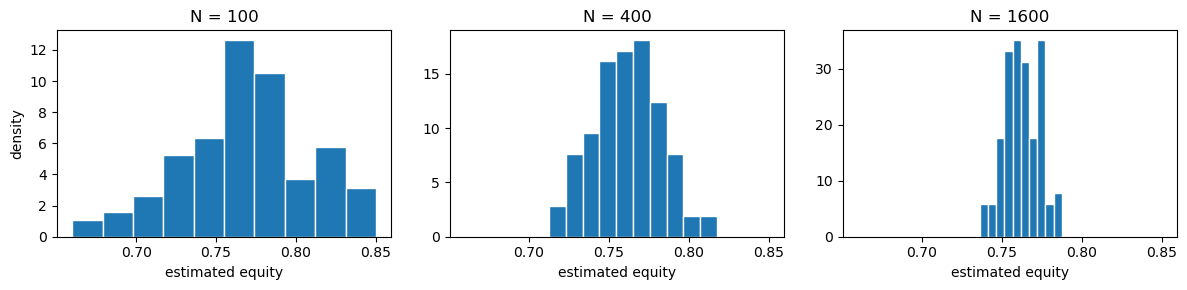

In [53]:
fig, axes = plt.subplots(1, len(N_values), figsize=(12, 3), sharex=True)

for index in range(len(N_values)):
    N = N_values[index]
    axes[index].hist(estimates_by_N[N], bins=10, density=True, edgecolor="white")
    axes[index].set_title("N = " + str(N))
    axes[index].set_xlabel("estimated equity")

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

> **Let's compare results:** What stayed approximately fixed? What shrank? 



## What happens when we change `M`?

`N` is the number of games in **one** equity estimate. `M` is the number of times we repeat that entire estimate.

> **Predict before we run this:** Keep `N` fixed. If we increase `M`, what happens to the width and smoothness of the observed distribution?

> **While it runs:** How does the total cost `M * N` change across the three experiments? Does spending more here make each individual equity estimate more accurate?



In [ ]:
N = 500
M_values = [25, 100, 500]
estimates_by_M = {}

for M in M_values:
    estimates = repeated_estimates(
        M, N, your_cards, known_community_cards, rng
    )
    estimates_by_M[M] = estimates

    print(
        "M =", M,
        "  mean =", np.mean(estimates),
        "  estimated standard error =", np.std(estimates, ddof=1),
    )

> **Let's compare results:** As `M` increases, what happens to the smoothness of the histogram? What happens to the measured mean and estimated standard error? Does the underlying width appear to change?



In [ ]:
fig, axes = plt.subplots(1, len(M_values), figsize=(10, 3), sharex=True)

for index in range(len(M_values)):
    M = M_values[index]
    estimates = estimates_by_M[M]
    axes[index].hist(estimates, bins=15, density=True, edgecolor="white")
    axes[index].set_title("M = " + str(M))
    axes[index].set_xlabel("estimated equity")

axes[0].set_ylabel("density")
plt.suptitle("Fixed N = " + str(N))
plt.tight_layout()
plt.show()

## Cost and convergence

One equity estimate using `N` games calls `play_round` `N` times, so its computational cost grows linearly with `N`.

Let $X$ be the numerical outcome of one randomly simulated game: the value assigned to a win, tie, or loss. The true equity is the expected value

$$E = \mathbb{E}[X].$$

Let $X_i$ be the outcome of simulated game $i$. Each game uses the same poker scenario and is simulated independently. The estimated equity is computed using the sample mean of these `N` outcomes:

$$\widehat{E} = \frac{1}{N}\sum_{i=1}^{N} X_i.$$

Let $\sigma$ be the standard deviation of $X$, so $\sigma$ measures how much individual simulated-game outcomes vary. The standard error of the equity estimate is

$$\mathrm{SE}(\widehat{E}) = \frac{\sigma}{\sqrt{N}}.$$

Therefore, multiplying `N` by 4 should make the variability of the equity estimate approximately 2 times smaller.

> **Accuracy-cost tradeoff:** Suppose the estimated standard error is about `0.04` when `N = 100`. Approximately what `N` would reduce it to `0.01`, and how many times more work would that require?

For each `N`, we use the `M` equity estimates to estimate $\mathrm{SE}(\widehat{E})$.

> **Construct a convergence plot:** On logarithmic axes, plot the estimated standard error of the equity estimate versus `N`. Add a reference curve proportional to $1/\sqrt{N}$.

The expression $1/\sqrt{N}$ determines the shape of the reference curve but not its vertical position. We scale it to pass through the first observed point $(N_1, e_1)$:

$$e_{\mathrm{reference}}(N) = e_1\sqrt{\frac{N_1}{N}}.$$

This reference curve is a guide for comparing the convergence trend. It is not a prediction of the exact error at every `N`.



In [ ]:
N_plot = np.array(N_values, dtype=float)

estimated_standard_errors_by_N = []
for N in N_values:
    estimated_standard_error = np.std(estimates_by_N[N], ddof=1)
    estimated_standard_errors_by_N.append(estimated_standard_error)
estimated_standard_errors_by_N = np.array(estimated_standard_errors_by_N)

# Scale the reference curve to begin at the first observed point.
first_N = N_plot[0]
first_error = estimated_standard_errors_by_N[0]
reference_inverse_sqrt_N = first_error * np.sqrt(first_N / N_plot)

plt.loglog(N_plot, estimated_standard_errors_by_N, "o-", label="estimated standard error")
plt.loglog(N_plot, reference_inverse_sqrt_N, "--", label=r"$O(1/\sqrt{N})$")
plt.xlabel("number of simulated games, N")
plt.ylabel("estimated standard error")
plt.title("Convergence of the Monte Carlo estimate")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

### What does the plot tell us?

Discuss:

- Does the Monte Carlo estimate converge as `N` increases?
- Why is $O(1/\sqrt{N})$ considered a slow convergence rate?



## Return to the opening question

> How many games are enough to **trust** the equity estimate?

There is no universal answer. More games make each estimate less variable, but they also cost more. “Enough” depends on how much uncertainty is acceptable for the decision.

## Takeaway

A Monte Carlo estimate is a sample mean of numerical random outcomes. Increasing `N` reduces the variability of each estimate approximately like $1/\sqrt{N}$. Increasing `M` does not narrow the distribution of individual `N`-game equity estimates; it lets us observe that distribution more clearly.